(sec:dim_reduction)=

# Dimensionality Reduction

- so far, in supervised learning, we have considered problems where we have data of the form $(x_i, y_i)_{i=1}^N$ and are interested in modelling the relation between features $x$ and labels $y$
- next, we will introduce techniques that allow us to uncover patterns in the data if no labels are available (unsupervised learning)
- in this chapter, we will focus on dimensionality reduction, i.e. the problem of finding a low-dimensional representation of our data while preserving as much of the original information as possible

## Theoretical Foundations

### Principal Component Analysis

- idea of pca is to find a lower-dimensional coordinate system in which each data point is only represented by $k < d$ features

- transformation in a new coordinate system is defined by a projection matrix $\bm{V}_k$ with $k < d$ columns, such that multiplying our data matrix $\bm{X} \in \mathbb{R}^{N \times d}$[^1] with $\bm{V}_k$ yields a new matrix $\bm{Z}_k \in \mathbb{R}^{N \times k}$ of our data in the new coordinate system

$$
\bm{Z}_k 
= 
\bm{X} \bm{V}_k
$$

[^1]: We do not need to add an extra column of ones to $\bm{X}$ here, since there are no weights or biases to fit.

- the task of finding the optimal projection matrix $\bm{V}_k$ can be guided by the principle that the reconstruction of $\bm{X}$ from $\bm{Z}_k$ should be as close as possible to the original data

- recall from {ref}`sec:singular_value_decomposition` that the low-rank approximation of a matrix given by its compact SVD 

$$
\bm{X}_k 
= 
\bm{U}_k \bm{\Sigma}_k \bm{V}_k^T 
= 
\sum_{i=1}^k \sigma_i \vec{u}_i \vec{v}_i^T
$$

- is the best possible rank-$k$ approximation of $\bm{X}$ in the sense of the Frobenius norm

- this means that the projection matrix $\bm{V}_k$ that we are looking for is given by the first $k$ columns of $\bm{V}$ (right singular vectors) in the SVD of $\bm{X}$, which are called the **principal components** 

- we can take advantage of the fact that the columns of $\bm{V}$ correspond to the eigenvectors of the covariance matrix $\bm{X}^T \bm{X}$

$$
\bm{X}^T \bm{X} 
=
(\bm{U} \bm{\Sigma} \bm{V}^T)^T \bm{U} \bm{\Sigma} \bm{V}^T
=
\bm{V} \bm{\Sigma} \underbrace{\bm{U}^T \bm{U}}_{=1\kern-0.25em\text{l}} \bm{\Sigma} \bm{V}^T
=
\bm{V} \bm{\Sigma}^2 \bm{V}^T,
$$

- the eigenvalues of $\bm{X}^T \bm{X}$ (squares of the singular values $\sigma_i$ of $\bm{X}$) denote the contribution of each principal component and, when normalised, are called the **explained variances**

:::{note} Mathematical details
:class: dropdown

- start from the compact SVD 

$$
\bm{X}_k 
= 
\bm{U}_k \bm{\Sigma}_k \bm{V}_k^T
$$

- projecting the rank-$k$ approximation of $\bm{X}$ onto the first $k$ columns of $\bm{V}$ yields a matrix with $k$ columns, which we call $\bm{Z}_k$

$$
\bm{X}_k \bm{V}_k 
= 
\bm{U}_k \bm{\Sigma}_k \underbrace{\bm{V}_k^T \bm{V}_k}_{=1\kern-0.25em\text{l}} 
= 
\bm{U}_k \bm{\Sigma}_k
= 
\bm{Z}_k
$$

- now consider the full SVD of $\bm{X}$

$$
\bm{X} 
= 
\bm{U} \bm{\Sigma} \bm{V}^T
$$

- projecting the full data matrix onto $\bm{V}_k$ yields the same low-dimensional representation, as the product $\bm{V}^T \bm{V}_k$ selects the first $k$ coordinate directions:

$$
\bm{X} \bm{V}_k 
= 
\bm{U} \bm{\Sigma} \bm{V}^T \bm{V}_k 
= 
\bm{U} \bm{\Sigma}
\begin{pmatrix}
1_1    &        &        & 0 \\
       & \ddots &        &   \\
       &        & 1_k    &   \\
0      &        &        & 0
\end{pmatrix}
=
\bm{U}_k \bm{\Sigma}_k
=
\bm{Z}_k
$$

- the Eckart-Young-Mirsky theorem states that the reconstruction

$$
\bm{X}_k 
= 
\bm{Z}_k \bm{V}^T_k 
$$

- is the best possible rank-$k$ approximation of $\bm{X}$ in the sense of the Frobenius norm

:::

### Further Methods

- Because PCA is a **linear** dimensionality reduction method, it can only find flat directions through the original feature space, which is often very useful, but may miss curved or more complicated structures in the data.

- **t-SNE** (*t-distributed stochastic neighbor embedding*) is a nonlinear method that tries to preserve local neighborhoods: points that are close in the original feature space should also be close in the low-dimensional map. 

- It does this by converting pairwise distances into neighborhood probabilities and then moving points in the low-dimensional map until these probabilities are similar.

- It is often used for visualisation in two dimensions, especially when one wants to see whether data points form clusters.

- **UMAP** (*uniform manifold approximation and projection*) is another nonlinear method that also focuses on preserving neighborhood relationships, but is often faster than t-SNE and can better preserve some larger-scale structure. 

- It first builds a graph connecting nearby points in the original feature space and then lays out this graph in fewer dimensions.

- Like t-SNE, it is mostly used as an exploratory visualisation tool rather than as a direct replacement for PCA in mathematical modelling workflows.

## Implementation

- implementation of PCA is straightforward

- summarize steps:

1. center the data matrix $\bm{X}$ by subtracting the mean of each feature from the data points
2. compute the eigenvalues and eigenvectors of the covariance matrix $\bm{X}^T \bm{X}$
3. if not already sorted by decreasing eigenvalues, do so
4. project the data onto the first $k$ eigenvectors

- start by implementing the constructor, where we initialize placeholder attributes for the column means, the projection matrix $\bm{V}_k$ and the explained variances $\sigma^2_i$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
class PrincipalComponentAnalysis:
    def __init__(self, k=2):
        self.k = k
        self.mean = None
        self.components = None
        self.explained_variance = None

- following the steps outlined above, in the `fit` method, we use [`np.cov`](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) to compute $\bm{X}^T \bm{X}$

- note that `np.linalg.eigh` returns the eigenvalues and eigenvectors in ascending order, so we take the **last** $k$ columns (`[:, -self.k:]`) and reverse their order by slicing with `[:, ::-1]`

In [3]:
    def fit(self, X):
        # Center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        
        # Compute the covariance matrix
        cov_matrix = np.cov(X_centered, rowvar=False)
        
        # Compute the eigenvalues and eigenvectors (ascending order)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        
        # Store the top k eigenvectors (principal components)
        self.components = eigenvectors[:, -self.k:][:, ::-1]
        
        # Calculate the explained variances of all principal components
        self.explained_variance = eigenvalues[::-1] / np.sum(eigenvalues)
        
        return self

- because we do not have associated labels with our data, we do not need a `predict` method but implement the projection of data onto the principal components in the `transform` method
- here, we reuse the mean from the `fit` method such that new data is projected using the same centering convention than the training data.

In [4]:
    def transform(self, X):
        # Project the data onto the first k principal components
        X_centered = X - self.mean
        return X_centered @ self.components
    
    def fit_transform(self, X):
        # Fit the model and return the transformed data
        return self.fit(X).transform(X)

:::{tip} Full implementation
:class: dropdown

The complete PCA class is shown below, including explanatory docstrings.

```python
class PrincipalComponentAnalysis:
    """A simple principal component analysis model.

    The model centers the training data, computes the covariance matrix,
    and uses its leading eigenvectors as principal component directions.
    New data are centered with the training mean before projection.

    Parameters
    ----------
    k : int
        Number of principal components to keep.

    Attributes
    ----------
    k : int
        Number of principal components stored on the model.
    mean : 1d-array or None
        Feature-wise mean of the training data. This is used to center data
        before projection.
    components : 2d-array or None
        Matrix whose columns are the first k principal component directions.
    explained_variance : 1d-array or None
        Fraction of total variance explained by each principal component.
    """

    def __init__(self, k=2):
        """Initialise the model hyperparameter and placeholder attributes."""
        self.k = k
        self.mean = None
        self.components = None
        self.explained_variance = None

    def fit(self, X):
        """Fit the principal component directions from the training data."""
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        self.components = eigenvectors[:, -self.k:][:, ::-1]
        self.explained_variance = eigenvalues[::-1] / np.sum(eigenvalues)
        return self

    def transform(self, X):
        """Project data onto the fitted principal component directions."""
        X_centered = X - self.mean
        return X_centered @ self.components

    def fit_transform(self, X):
        """Fit the model and return the projected training data."""
        self.fit(X)
        return self.transform(X)
```

:::

In [5]:
class PrincipalComponentAnalysis:
    """A simple principal component analysis model.

    The model centers the training data, computes the covariance matrix,
    and uses its leading eigenvectors as principal component directions.
    New data are centered with the training mean before projection.

    Parameters
    ----------
    k : int
        Number of principal components to keep.

    Attributes
    ----------
    k : int
        Number of principal components stored on the model.
    mean : 1d-array or None
        Feature-wise mean of the training data. This is used to center data
        before projection.
    components : 2d-array or None
        Matrix whose columns are the first k principal component directions.
    explained_variance : 1d-array or None
        Fraction of total variance explained by each principal component.
    """

    def __init__(self, k=2):
        """Initialise the model hyperparameter and placeholder attributes."""
        self.k = k
        self.mean = None
        self.components = None
        self.explained_variance = None

    def fit(self, X):
        """Fit the principal component directions from the training data."""
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        self.components = eigenvectors[:, -self.k:][:, ::-1]
        self.explained_variance = eigenvalues[::-1] / np.sum(eigenvalues)
        return self

    def transform(self, X):
        """Project data onto the fitted principal component directions."""
        X_centered = X - self.mean
        return X_centered @ self.components

    def fit_transform(self, X):
        """Fit the model and return the projected training data."""
        self.fit(X)
        return self.transform(X)

## Application

- let us now apply PCA to a problem from current research in chemistry

- in an ongoing project, we are interested in how solvent molecules can interact with polycyclic aromatic hydrocarbons (PAHs)

- therefore, we have performed simulations that yield the geometries of 18 conformational isomers of Quinoline ($\mathrm{C_9H_7N}$) with Chloroform ($\mathrm{CHCl}_3$), which are shown in the following figure

![Conformers of Quinoline and Chloroform](/assets/figures/data_driven_modelling/Conformers.pdf)

- to characterise the geometries, we have constructed features by determining 500 distances and angles between pairs and triplets of atoms in different parts of the molecule, respectively

- you can download the data here: {download}`/assets/data/data_driven_modelling/conformers.csv`

In [6]:
df = pd.read_csv('conformers.csv')
df.head()

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_490,dim_491,dim_492,dim_493,dim_494,dim_495,dim_496,dim_497,dim_498,dim_499
0,6.484415,6.512751,7.209587,7.813031,5.598746,5.197558,5.413828,6.115553,6.833008,4.616440,...,79.389142,90.481568,92.006819,106.034017,86.401973,94.009786,107.630235,108.536841,128.041265,100.727465
1,6.341733,6.320978,6.514812,7.882226,5.540070,5.166577,5.183634,5.243819,6.842093,4.540198,...,80.086785,86.878528,79.817664,103.500907,85.057806,93.447891,102.805004,94.384389,124.929265,98.862557
2,6.411415,6.333558,6.474849,7.895143,5.549329,5.188125,5.193691,5.240514,6.852813,4.550481,...,79.809273,87.000291,80.310442,103.580702,85.226705,93.735987,103.027782,94.549625,125.100377,99.115631
3,4.674616,3.747897,4.394519,4.724341,2.681700,4.055627,3.666855,4.653286,4.778704,2.663429,...,58.761196,50.015181,46.434323,67.348889,38.306088,63.065673,49.510637,45.541052,62.730972,37.552920
4,4.653232,3.704199,4.825569,4.124101,2.692573,4.586104,3.830451,4.674146,4.785078,2.752492,...,50.719738,48.803035,70.339445,48.139592,37.974847,51.597802,46.569381,67.486438,42.158927,36.742968


- given the small number of data points, the large number of features makes it difficult to reason about the data or fit a model without risking severe overfitting
- therefore, we will apply PCA to reduce the dimensionality of the data from $d = 500$ to $k = 2$
- all we have to do is to create an instance of the `PrincipalComponentAnalysis` class and call the `fit_transform` method of the instance with our data matrix as argument

In [7]:
X = df.values
pca = PrincipalComponentAnalysis(k=2)
Z = pca.fit_transform(X)
print(Z.shape)

(18, 2)


- we can now plot the data in the low-dimensional space spanned by the first two principal components
- [`plt.annotate`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html) allows us to label the data points with their corresponding index from the figure above

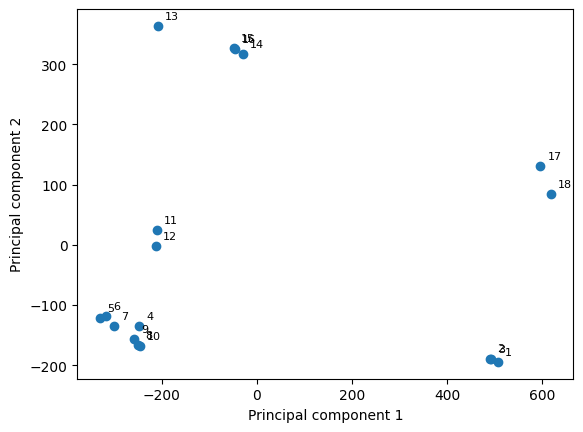

In [8]:
plt.plot(Z[:, 0], Z[:, 1], 'o')
for i, (x, y) in enumerate(zip(Z[:, 0], Z[:, 1])):
    plt.annotate(str(i+1), (x, y), textcoords="offset points", xytext=(5,5), ha='left', fontsize=8)
plt.xlabel('Principal component 1')
plt.ylabel('Principal component 2')
plt.show()

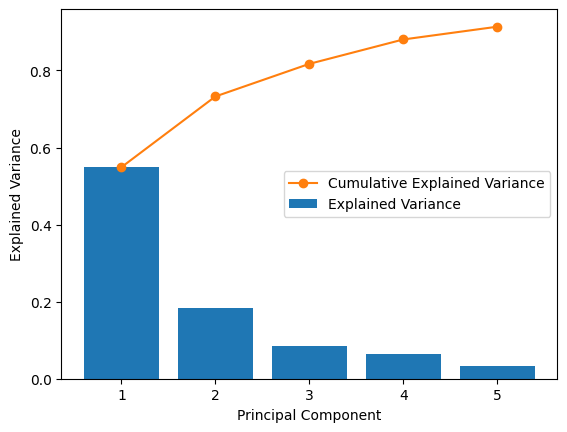

In [11]:
n = 5

plt.bar(range(1, n + 1), pca.explained_variance[:n], color='tab:blue', label='Explained Variance')
plt.plot(range(1, n + 1), np.cumsum(pca.explained_variance[:n]), 'o-', c='tab:orange', label='Cumulative Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.legend()
plt.show()

## Self-Study Questions

1. 